# NIST TN 1822 — Verif.3.1: Exit route allocation

NIST TN 1822 Figure 8: 12 rooms around a 1 m corridor, main exit at the top and a secondary exit on the right. Rooms 1,2,3,4,7,8,9,10 are allocated to the main exit; rooms 5,6,11,12 to the secondary exit.

Helpers (`agent_to_distribution`, `agent_to_actual_exit`) are reused from the canonical rimea10 notebook.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 23 May 2026, 21:40 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load the scenario and the encoded route allocation

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Nist-3-1-route-allocation.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())
journey_map = {j['stages'][0]: j['stages'][-1] for j in scenario.raw['journeys']}
print('expected assignment:', journey_map)

Scenario: /work/standards/nist/scenario_files/Nist-3-1-route-allocation.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      180s
  Exits:         2
  Distributions: 12
  Stages:        0
  Zones:         0
  Journeys:      12
  Agents:        ~23
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 2 agents
    jps-distributions_1: 2 agents
    jps-distributions_2: 1 agents
    jps-distributions_3: 2 agents
    jps-distributions_4: 2 agents
    jps-distributions_5: 2 agents
    jps-distributions_6: 2 agents
    jps-distributions_7: 2 agents
    jps-distributions_8: 2 agents
    jps-distributions_9: 2 agents
    jps-distributions_10: 2 agents
    jps-distributions_11: 2 agents
expected assignment: {'jps-distributions_0': 'jps-exits_0', 'jps-distributions_1': 'jps-exits_0', 'jps-distributions_2': 'jps-exits_0', 'jps-distributions_3': 'jps-exits_0', 'jps-distribut

## Helper functions (from rimea10_route_allocation.ipynb)

In [5]:
def agent_to_distribution(trajectory, distributions):
    first = trajectory.data.sort_values(['id', 'frame']).groupby('id').first().reset_index()
    polys = {k: Polygon(v['coordinates']) for k, v in distributions.items()}
    mapping = {}
    for row in first.itertuples():
        point = Point(row.x, row.y)
        for did, poly in polys.items():
            if poly.covers(point):
                mapping[row.id] = did
                break
    return mapping

def agent_to_actual_exit(trajectory, exits):
    last = trajectory.data.sort_values(['id', 'frame']).groupby('id').last().reset_index()
    polys = {k: Polygon(v['coordinates']) for k, v in exits.items()}
    return {
        row.id: min(polys, key=lambda eid: polys[eid].distance(Point(row.x, row.y)))
        for row in last.itertuples()
    }

## Run the scenario

In [6]:
result = run_scenario(scenario, seed=42)
trajectory = pedpy.TrajectoryData(
    result.trajectory_dataframe()[['id', 'frame', 'x', 'y']].copy(),
    frame_rate=result.frame_rate,
)

DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 2, 'radius': 0.15, 'v0': 1.2, 'distribution_mode': 'by_number', 'radius_distribution': 'constant', 'v0_distribution': 'constant', 'use_flow_spawning': False}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 2, 'radius': 0.15, 'v0': 1.2, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None, 'distribution_mode': 'by_number', 'percentage': None}
DEBUG: Distribution jps-distributions_1 RAW params from JSON: {'number': 2, 'radius': 0.15, 'v0': 1.2, 'distribution_mode': 'by_number', 'radius_distribution': 'constant', 'v0_distribution': 'constant', 'use_flow_spawning': False}
DEBUG: Distribution jps-distributions_1 processed params: {'numbe

## Map each agent to expected vs actual exit

In [7]:
homes = agent_to_distribution(trajectory, scenario.distributions)
actuals = agent_to_actual_exit(trajectory, scenario.exits)
rows = [
    {'agent': int(aid), 'home': homes.get(aid),
     'expected_exit': journey_map.get(homes.get(aid)),
     'actual_exit': actuals[aid]}
    for aid in actuals
]
assignment = pd.DataFrame(rows)
assignment['matches'] = assignment['expected_exit'] == assignment['actual_exit']
assignment

,agent,home,expected_exit,actual_exit,matches
0,1,jps-distributions_0,jps-exits_0,jps-exits_0,True
1,2,jps-distributions_0,jps-exits_0,jps-exits_0,True
2,3,jps-distributions_1,jps-exits_0,jps-exits_0,True
3,4,jps-distributions_1,jps-exits_0,jps-exits_0,True
4,5,jps-distributions_2,jps-exits_0,jps-exits_0,True
5,6,jps-distributions_3,jps-exits_0,jps-exits_0,True
6,7,jps-distributions_3,jps-exits_0,jps-exits_0,True
7,8,jps-distributions_4,jps-exits_1,jps-exits_1,True
8,9,jps-distributions_4,jps-exits_1,jps-exits_1,True
9,10,jps-distributions_5,jps-exits_1,jps-exits_1,True


## Plot trajectories coloured by allocated exit

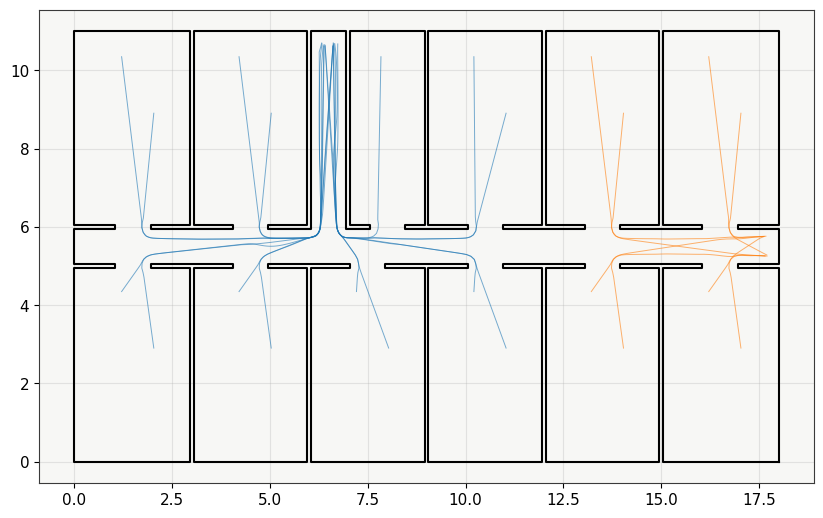

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
x, y = scenario.walkable_polygon.exterior.xy
ax.plot(x, y, 'k-')
for interior in scenario.walkable_polygon.interiors:
    ix, iy = interior.xy
    ax.plot(ix, iy, 'k-', lw=0.8)
colors = {'jps-exits_0': 'tab:blue', 'jps-exits_1': 'tab:orange'}
df = trajectory.data
for agent_id, sub in df.sort_values('frame').groupby('id'):
    row = assignment[assignment.agent == agent_id]
    if len(row) == 0:
        continue
    ax.plot(sub.x, sub.y, color=colors.get(row.iloc[0].expected_exit, 'k'),
            alpha=0.6, lw=0.7)
ax.set_aspect('equal')
plt.show()

## Acceptance

In [9]:
match_rate = assignment['matches'].mean()
print(f'allocation match rate: {match_rate:.1%}')
assert match_rate == 1.0, assignment[~assignment['matches']]
result.cleanup()

allocation match rate: 100.0%
